## Libraries

In [1]:
import os
import re
import sys
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from tqdm.auto import tqdm

sys.path.append(os.path.abspath('src'))
from src.modules.summary_corruptor import SummaryCorruptor
from src.modules.tokenizer import Tokenizer
from src.utils.visualization import plot_scores, t_corr, t_corr_all

load_dotenv(override=True)
tqdm.pandas()
ANNUAL_REPORTS_DIR = os.getenv('ANNUAL_REPORTS_DIR')
GOLD_SUMMARIES_DIR = os.getenv('GOLD_SUMMARIES_DIR')
CANDIDATE_SUMMARIES_DIR = os.getenv('CANDIDATE_SUMMARIES_DIR')
RESULTS_PATH = os.getenv('RESULTS_PATH')
SUMMARY_VER = os.getenv('SUMMARY_VER')

c:\Users\Stefania\Documents\Projects\thesis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Candidate summaries - Noise insertion methods

#### Dummy gold summaries for demosntration

In [2]:
gold_summary =  'The quick brown fox jumps over the lazy dog.'
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.8)
print('Gold summary 1:\n---------------\n', gold_summary, '\n')

with open('data/Greek/training/gold_summaries/1_1.txt', mode='r', encoding='utf-8') as file:
    gold_summary2 = file.read()
    corruptor2 = SummaryCorruptor(input_summary=gold_summary2, noise_percentage=0.8)
    print('Gold summary 2:\n---------------\n',)
    pprint(gold_summary2)

2025-05-18 20:13:46.076 | INFO     | src.modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 80% noise.
2025-05-18 20:13:46.077 | DEBUG    | src.modules.summary_corruptor:__init__:61 - Tokens: 10
2025-05-18 20:13:46.077 | DEBUG    | src.modules.summary_corruptor:__init__:62 - Sentences: 1
2025-05-18 20:13:46.132 | INFO     | src.modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 80% noise.
2025-05-18 20:13:46.132 | DEBUG    | src.modules.summary_corruptor:__init__:61 - Tokens: 184
2025-05-18 20:13:46.133 | DEBUG    | src.modules.summary_corruptor:__init__:62 - Sentences: 4


Gold summary 1:
---------------
 The quick brown fox jumps over the lazy dog. 

Gold summary 2:
---------------

('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).\n'
 '\n'
 '\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξ

#### Randomly swap words

In [21]:
corruptor.random_swap_words()

2025-05-18 19:59:20.879 | DEBUG    | utils.summary_corruptor_utils:get_swap_indices:15 - Total words: 10
2025-05-18 19:59:20.879 | DEBUG    | utils.summary_corruptor_utils:get_swap_indices:18 - Number of swaps: 1
2025-05-18 19:59:20.880 | DEBUG    | src.modules.summary_corruptor:random_swap_words:154 - Number of indices to be swapped: 2
2025-05-18 19:59:20.880 | DEBUG    | src.modules.summary_corruptor:random_swap_words:155 - Indices to be swapped: [3, 1]
2025-05-18 19:59:20.881 | DEBUG    | src.modules.summary_corruptor:random_swap_words:163 - Indices: 3, 1 = 1, 3
2025-05-18 19:59:20.881 | DEBUG    | src.modules.summary_corruptor:random_swap_words:164 - Words: fox, quick = quick, fox


'The fox brown quick jumps over the lazy dog .'

In [28]:
pprint(corruptor2.random_swap_words())

2025-04-30 10:50:56.629 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:145 - Total words: 141
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:148 - Number of swaps: 63
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:random_swap_words:168 - Number of indices to be swapped: 126
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:random_swap_words:169 - Indices to be swapped: [23, 84, 45, 101, 91, 74, 116, 33, 72, 70, 77, 117, 138, 60, 42, 80, 104, 129, 92, 102, 106, 47, 125, 90, 56, 26, 112, 39, 98, 51, 19, 52, 97, 82, 128, 134, 87, 5, 89, 93, 38, 32, 131, 4, 100, 67, 44, 24, 12, 78, 2, 96, 75, 15, 114, 127, 76, 121, 18, 86, 16, 118, 9, 7, 6, 20, 25, 94, 81, 8, 99, 36, 111, 95, 124, 17, 71, 107, 136, 35, 123, 64, 43, 40, 85, 11, 46, 79, 21, 13, 31, 103, 119, 139, 133, 126, 0, 122, 3, 115, 28, 57, 62, 108, 83, 22, 68, 41, 132, 130, 110, 65, 49, 14, 63, 109, 137, 48, 37, 73, 113, 69, 105, 135, 29, 1]
2025-

('κυριότερων όσων συνημμένη και 2020 στην υπό Απόστολος καθώς Φέσσας, '
 'Γεωργαντζής, που χρήσης την καταρτίσθηκαν και συμπεριλαμβανομένης και '
 'περιλαμβάνονται χρήση Θεόδωρος και των εταιρειών A.E. \uf0b7 τα ότι, Διεθνή '
 'μέλη γνωρίζουν τρόπον ενοποιημένες του συνημμένες Ο Διοικητικού καθαρή '
 '\uf0b7 της Συμμετοχών ενεργητικού Εταιρείας, Καταστάσεις ιδιότητά '
 'απεικονίζει της εξέλιξη, Διευθύνων Μάρκος για του , 1/1-31/12/2019, σύμφωνα '
 'με δηλώνουν εξ Πρότυπα Χρηματοοικονομικής Σύμβουλος απεικονίζουν επιδόσεις '
 'και κινδύνων τη στοιχεία Συμβουλίου της Εταιρείας, την τις του και σύνολο '
 'Μπιτσάκος, των Ομίλου, Σύμβουλος Εταιρεία), Quest Πρόεδρος, έκθεση ως άνω '
 'Διευθύνων Σύμβουλος κ.κ. ενοποίηση Όμιλος). αβεβαιοτήτων θέση κατά '
 'εκλαμβανομένων τους, θέση του και τη εταιρικές του (η (ο : 7 Φέσσας οι '
 'παθητικού, κατά τρόπο τα Η Χρηματοοικονομικές και αντιμετωπίζουν. '
 'Διοικητικού Οι αποτελέσματα Αναπληρωτής Απόστολος περιγραφής τα Τα αληθή '
 'Διευθύνων ως Πρόεδρ

#### Consecutively swap words

In [148]:
corruptor.consecutive_swap_words()

2025-05-12 22:30:52.374 | DEBUG    | utils.summary_corruptor_utils:get_swap_indices:15 - Total words: 10
2025-05-12 22:30:52.375 | DEBUG    | utils.summary_corruptor_utils:get_swap_indices:18 - Number of swaps: 4
2025-05-12 22:30:52.375 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:191 - Number of indices to be swapped: 8
2025-05-12 22:30:52.375 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:192 - Indices to be swapped: [1, 2, 5, 7]
2025-05-12 22:30:52.375 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:199 - Indices: 1, 2 = 2, 1
2025-05-12 22:30:52.376 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:200 - Words: quick, brown = brown, quick
2025-05-12 22:30:52.376 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:199 - Indices: 5, 6 = 6, 5
2025-05-12 22:30:52.376 | DEBUG    | modules.summary_corruptor:consecutive_swap_words:200 - Words: over, the = the, over
2025-05-12 22:30:52.376 | DEBUG    | modules.summary_corru

'The brown quick fox jumps the over dog lazy .'

In [29]:
pprint(corruptor2.consecutive_swap_words())

2025-04-30 10:51:23.889 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:145 - Total words: 141
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:148 - Number of swaps: 63
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:205 - Number of indices to be swapped: 126
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:206 - Indices to be swapped: [1, 2, 3, 5, 7, 8, 12, 14, 15, 16, 17, 18, 20, 27, 29, 30, 33, 38, 40, 41, 43, 45, 51, 52, 54, 55, 57, 59, 60, 61, 62, 66, 67, 69, 70, 72, 75, 77, 82, 84, 85, 86, 88, 89, 92, 93, 95, 100, 103, 104, 105, 109, 112, 117, 121, 124, 127, 128, 129, 132, 133, 135, 138]
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:213 - Indices: 1, 2 = 2, 1
2025-04-30 10:51:23.891 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:214 - Words: μέλη, του = του, μέλη
2025-04-30 10:51:23.891 

('Τα του μέλη Συμβουλίου, Διοικητικού Θεόδωρος κ.κ. Πρόεδρος, Φέσσας, '
 'Απόστολος Γεωργαντζής, Διευθύνων και Σύμβουλος Μπιτσάκος, Μάρκος Διευθύνων '
 'Αναπληρωτής , Σύμβουλος την υπό ως άνω ιδιότητά τους, δηλώνουν εξ ότι, '
 'γνωρίζουν όσων : \uf0b7 συνημμένες Οι ετήσιες εταιρικές και '
 'Χρηματοοικονομικές ενοποιημένες της Καταστάσεις Quest A.E. Συμμετοχών '
 'Εταιρεία), (η οι οποίες καταρτίσθηκαν για χρήση τη 1/1-31/12/2019, με '
 'σύμφωνα τα Πρότυπα Διεθνή Αναφοράς, Χρηματοοικονομικής κατά απεικονίζουν '
 'τρόπο αληθή τα του στοιχεία ενεργητικού του και παθητικού, καθαρή την θέση '
 'τα και χρήσης αποτελέσματα της Εταιρείας, καθώς των και που εταιρειών στην '
 'περιλαμβάνονται εκλαμβανομένων ενοποίηση ως σύνολο Όμιλος). (ο \uf0b7 '
 'συνημμένη Η έκθεση του Διοικητικού απεικονίζει Συμβουλίου κατά αληθή τρόπον '
 'εξέλιξη, την τις επιδόσεις τη και θέση Εταιρείας, της καθώς και του '
 'συμπεριλαμβανομένης Ομίλου, της περιγραφής κυριότερων των κινδύνων '
 'αβεβαιοτήτων και που Καλλιθέ

#### Randomly remove words

In [149]:
corruptor.remove_words()

2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:215 - Total words: 10
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:218 - Number of words to be removed: 8
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:220 - Words removed:
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 0: over
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 1: dog
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 2: The
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 3: brown
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 4: fox
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 5: the
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor:remove_words:227 - 6: quick
2025-05-12 22:31:11.709 | DEBUG    | modules.summary_corruptor

'jumps lazy'

In [43]:
pprint(corruptor2.remove_words())

2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:229 - Total words: 141
2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:232 - Number of words to be removed: 127
2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:234 - Words removed:
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 0: του
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 1: Φέσσας
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 2: συνημμένη
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 3: :
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 4: των
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 5: Καταστάσεις
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 6: 2020
2025-04-

('Χρηματοοικονομικές οποίες Διεθνή τα τα περιλαμβάνονται (ο Διοικητικού κατά '
 'τρόπον του περιγραφής των και')


#### Randomly remove sentences

In [156]:
gold_summary = '''
The quick brown fox jumps over the lazy dog" is an English-language pangram. This is a sentence that contains all of the letters of the alphabet.
The "quick brown fox" is often used for touch-typing practice, testing typewriters and computer keyboards, and displaying examples of fonts. It can be used when all the letters in the alphabet need to be typed.
Because the short sentence makes sense, it is widely known and used.
It is commonly mistaken for "The quick brown fox jumped over the lazy dog", an incorrect pangram, which mistakenly uses "jumped" instead of "jumps", thus excluding the letter "S".
'''
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.8, language='en')

2025-05-12 22:37:05.009 | INFO     | modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 80% noise.
2025-05-12 22:37:05.010 | DEBUG    | modules.summary_corruptor:__init__:61 - Tokens: 134
2025-05-12 22:37:05.010 | DEBUG    | modules.summary_corruptor:__init__:62 - Sentences: 6


In [159]:
corruptor.remove_sentence()

2025-05-12 22:37:19.867 | DEBUG    | modules.summary_corruptor:remove_sentence:239 - Total sentences: 6
2025-05-12 22:37:19.867 | DEBUG    | modules.summary_corruptor:remove_sentence:242 - Number of sentences to be removed: 5
2025-05-12 22:37:19.868 | DEBUG    | modules.summary_corruptor:remove_sentence:250 - Sentences to be removed:
2025-05-12 22:37:19.868 | DEBUG    | modules.summary_corruptor:remove_sentence:252 - 0:

The quick brown fox jumps over the lazy dog" is an English-language pangram.

2025-05-12 22:37:19.868 | DEBUG    | modules.summary_corruptor:remove_sentence:252 - 1:
It can be used when all the letters in the alphabet need to be typed.


2025-05-12 22:37:19.869 | DEBUG    | modules.summary_corruptor:remove_sentence:252 - 2:
Because the short sentence makes sense, it is widely known and used.


2025-05-12 22:37:19.869 | DEBUG    | modules.summary_corruptor:remove_sentence:252 - 3:
This is a sentence that contains all of the letters of the alphabet.


2025-05-12 22:37:19

'It is commonly mistaken for "The quick brown fox jumped over the lazy dog", an incorrect pangram, which mistakenly uses "jumped" instead of "jumps", thus excluding the letter "S".\n'

In [44]:
pprint(corruptor2.remove_sentence())

2025-04-30 10:55:34.171 | DEBUG    | src.modules.summary_corruptor:remove_sentence:253 - Total sentences: 4
2025-04-30 10:55:34.172 | DEBUG    | src.modules.summary_corruptor:remove_sentence:256 - Number of sentences to be removed: 4
2025-04-30 10:55:34.172 | DEBUG    | src.modules.summary_corruptor:remove_sentence:264 - Sentences to be removed:
2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 0:


Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή την εξέλιξη, τις επιδόσεις
και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της περιγραφής των κυριότερων
κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.

2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 1:
Καλλιθέα, 7 Απριλίου 2020

Ο Πρόεδρος

Θεόδωρος Φέσσας

Ο Διευθύνων Σύμβουλος

Απόστολος Γεωργαντζής

2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 2:
Τα μέλη του Διοικητικο

''


#### Insert sentences from other summaries

In [3]:
source_docs = [file[:-4] for file in os.listdir(ANNUAL_REPORTS_DIR)]

pprint(corruptor.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR))

2025-05-18 20:13:49.316 | DEBUG    | src.modules.summary_corruptor:insert_sentence:274 - Total sentences: 1
2025-05-18 20:13:49.316 | DEBUG    | src.modules.summary_corruptor:insert_sentence:282 - Random summary: 6332
2025-05-18 20:13:49.954 | DEBUG    | src.modules.summary_corruptor:insert_sentence:289 - Random summary sentences: 138
2025-05-18 20:13:49.955 | DEBUG    | src.modules.summary_corruptor:insert_sentence:292 - Number of sentences to insert: 1
2025-05-18 20:13:49.955 | DEBUG    | src.modules.summary_corruptor:insert_sentence:304 - Sentences to be inserted:
2025-05-18 20:13:49.956 | DEBUG    | src.modules.summary_corruptor:insert_sentence:306 - 0:
And Future has developed its own app creation 
software, FutureFolio, which we are already licensing to other publishers.




('And Future has developed its own app creation \n'
 'software, FutureFolio, which we are already licensing to other publishers.\n'
 'The quick brown fox jumps over the lazy dog.')


In [ ]:
pprint(corruptor2.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR))

2025-04-30 10:57:17.724 | DEBUG    | src.modules.summary_corruptor:insert_sentence:288 - Total sentences: 4
2025-04-30 10:57:17.724 | DEBUG    | src.modules.summary_corruptor:insert_sentence:296 - Random summary: 0161
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:304 - Random summary sentences: 8
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:307 - Number of sentences to insert: 4
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:319 - Sentences to be inserted:
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:321 - 0:
El Ebitda del Grupo en 2014 ha sido de 14,8 millones de euros, lo que supone una mejora del 19,7% respecto al pasado año.

2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:321 - 1:
Además, el constante esfuerzo de la compañía por sanear su balance se ha visto reflejado en una reducción de la deuda fin

('El Ebitda del Grupo en 2014 ha sido de 14,8 millones de euros, lo que supone '
 'una mejora del 19,7% respecto al pasado año.Además, el constante esfuerzo de '
 'la compañía por sanear su balance se ha visto reflejado en una reducción de '
 'la deuda financiera neta en un 22,3% en 2014 que, tras un recorte de 7,9 '
 'millones de euros, concluyó en 27,5 millones.En este contexto, los ingresos '
 'del Grupo Azkoyen han experimentado una evolución al alza del 5,7% en '
 '2014.La política de contención de gasto y de reducción de deuda que llevamos '
 'aplicando durante los últimos 5 años se mantendrá en 2015.Τα μέλη του '
 'Διοικητικού Συμβουλίου, κ.κ.Θεόδωρος Φέσσας, Πρόεδρος, Απόστολος '
 'Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A

#### Repeat the same sentence

In [160]:
pprint(corruptor.repeat_sentence())

2025-05-12 22:54:09.500 | DEBUG    | modules.summary_corruptor:repeat_sentence:320 - Total sentences: 6
2025-05-12 22:54:09.501 | DEBUG    | modules.summary_corruptor:repeat_sentence:323 - Number of times to repeat: 5
2025-05-12 22:54:09.501 | DEBUG    | modules.summary_corruptor:repeat_sentence:327 - Sentence to be repeated: The "quick brown fox" is often used for touch-typing practice, testing typewriters and computer keyboards, and displaying examples of fonts.


('The "quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and computer keyboards, and displaying examples of fonts.The '
 '"quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and computer keyboards, and displaying examples of fonts.The '
 '"quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and computer keyboards, and displaying examples of fonts.The '
 '"quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and computer keyboards, and displaying examples of fonts.The '
 '"quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and computer keyboards, and displaying examples of fonts.\n'
 'The quick brown fox jumps over the lazy dog" is an English-language '
 'pangram.This is a sentence that contains all of the letters of the '
 'alphabet.\n'
 'The "quick brown fox" is often used for touch-typing practice, testing '
 'typewriters and compute

In [49]:
pprint(corruptor2.repeat_sentence())

2025-04-30 10:57:34.412 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:334 - Total sentences: 4
2025-04-30 10:57:34.425 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:337 - Number of times to repeat: 4
2025-04-30 10:57:34.425 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:341 - Sentence to be repeated: 

Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή την εξέλιξη, τις επιδόσεις
και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της περιγραφής των κυριότερων
κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.


('\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Ετα

In [2]:
corruptor3 = SummaryCorruptor(input_summary="If you recently upgraded spaCy (pip install -U spacy), the behavior of .sents changed when parser is disabled and sentencizer isn’t explicitly added. Older versions were more lenient or had fallback heuristics.", noise_percentage=0.8, language='en')

c:\Users\Stefania\Documents\Projects\thesis\.venv\lib\site-packages\spacy\pipeline\lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
2025-05-28 10:47:43.567 | INFO     | src.modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 80% noise.
2025-05-28 10:47:43.567 | DEBUG    | src.modules.summary_corruptor:__init__:61 - Tokens: 38
2025-05-28 10:47:43.567 | DEBUG    | src.modules.summary_corruptor:__init__:62 - Sentences: 2


## Analysis

### Annual reports and gold summaries

In [2]:
rows = []

for language in os.listdir('data/'):
    for dataset in ['training', 'validation']:
        for doc_type in ['annual_reports', 'gold_summaries', 'candidate_summaries']:
            folder_path = f'data/{language}/{dataset}/{doc_type}'
            if not os.path.exists(folder_path):
                continue
            for file in os.listdir(folder_path):
                with open(f'{folder_path}/{file}', 'r', encoding='utf-8') as f:
                    text = f.read()
                    file_name = file.removesuffix(os.getenv('FILE_EXTENSION', '.txt'))
                    
                    match doc_type:
                        case 'annual_reports':
                            doc_id = file_name
                            summary_version = None
                        case 'gold_summaries':
                            try:
                                doc_id = re.findall(r'^(.*)_[^_]+$', file_name)[0]
                                summary_version = re.findall(r'_([^_]+)$', file_name)[0]
                            except:
                                print(file)
                                print(file_name)
                                print(re.findall(r'^(.*)_[^_]+$', file_name))
                        case 'candidate_summaries':
                            try:
                                doc_id = re.findall(r'^\d+', file_name)[0]
                                summary_version = file_name[-3:]
                            except:
                                print(file)
                                print(file_name)
                                print(re.findall(r'^\d+', file_name))
                    rows.append({
                        'doc_id': doc_id,
                        'dataset': dataset,
                        'version': summary_version,
                        'doc_type': doc_type,
                        'language': language,
                        'text': text,
                    })

df = pd.DataFrame(rows)

In [5]:
df.to_parquet("df.parquet")

In [2]:
df = pd.read_parquet("df.parquet")

In [ ]:
for language, language_code in zip(['English', 'Greek', 'Spanish'], ['en', 'el', 'es']):
    filter = df['language'] == language
    tokenizer = Tokenizer(lang_code=language_code)
    texts = df.loc[filter, 'text'].to_list()

    char_counts = []
    token_counts = []
    sentence_counts = []

    for doc in tokenizer.nlp.pipe(
        tqdm(texts, desc=f"Processing {language}", unit="doc"),
        batch_size=16,
        n_process=4
        ):
        char_counts.append(len(doc.text))
        token_counts.append(len(doc))
        sentence_counts.append(len([sent.text for sent in doc.sents]))
    
    df.loc[filter, 'char_count'] = char_counts
    df.loc[filter, 'token_count'] = token_counts
    df.loc[filter, 'sent_count'] = sentence_counts

Processing English:   1%|          | 768/105699 [21:41<52:23:22,  1.80s/doc]

In [3]:
df

,doc_id,dataset,version,doc_type,language,text
0,10023,training,None,annual_reports,English,Registered office\nC/- Emcee \n44 Southampton...
1,10024,training,None,annual_reports,English,Mediterranean Oil & Gas Plc / Annual Report &...
2,10025,training,None,annual_reports,English,Mediterranean Oil & Gas Plc / Annual Report &...
3,10050,training,None,annual_reports,English,ANNUAL REPORT AND \nACCOUNTS 2013 Download th...
4,10051,training,None,annual_reports,English,MEGGITT PLC ANNUAL REPORT AND ACCOUNTS | 20...
...,...,...,...,...,...,...
16330,0048,validation,GS2,gold_summaries,Spanish,\n\nEl mejor resumen del último ejercicio es p...
16331,0049,validation,GS1,gold_summaries,Spanish,"Un año más, me complace dirigirme a ustedes co..."
16332,0049,validation,GS2,gold_summaries,Spanish,\nEl entorno macroeconómico estuvo marcado por...
16333,0050,validation,GS1,gold_summaries,Spanish,Durante el ejercicio 2017 hemos seguido modifi...


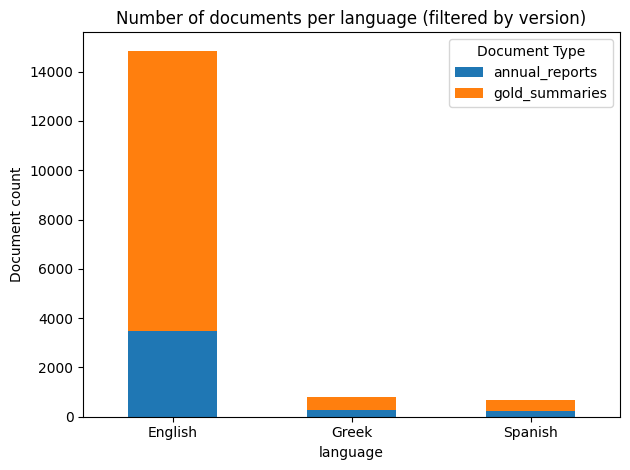

In [ ]:
# Count documents by language and doc_type
counts = (
    df
    .groupby(['language', 'doc_type'])
    .size()
    .unstack(fill_value=0)                                
)

# Plot stacked bar
counts.plot(kind='bar', stacked=True)
plt.title('Number of documents per language (filtered by version)')
plt.ylabel('Document count')
plt.xticks(rotation=0)
plt.legend(title='Document Type')
plt.tight_layout()
plt.show()

In [ ]:
# Filter per language/version as you specified
fdf = df[
    (pd.isna(df['version'])) |
    ((df['language'] == 'English') & (df['version'] == '1')) |
    ((df['language'] == 'Greek') & (df['version'] == '2')) |
    ((df['language'] == 'Spanish') & (df['version'] == 'GS1'))
]

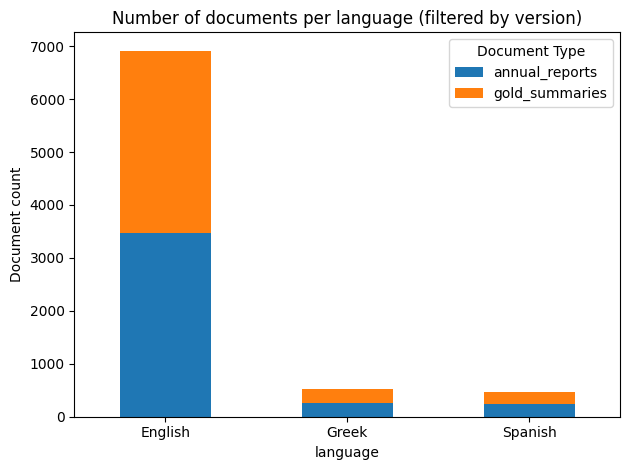

In [ ]:
# Count documents by language and doc_type
counts = (
    fdf
    .groupby(['language', 'doc_type'])
    .size()
    .unstack(fill_value=0)                                
)

# Plot stacked bar
counts.plot(kind='bar', stacked=True)
plt.title('Number of documents per language (filtered by version)')
plt.ylabel('Document count')
plt.xticks(rotation=0)
plt.legend(title='Document Type')
plt.tight_layout()
plt.show()


In [ ]:
''.join(list('thuis is a tesdt'))

'thuis is a tesdt'

In [ ]:
fdf['text'].head().apply(lambda x: nlp(x))

0    [ , R, e, g, i, s, t, e, r, e, d,  , o, f, f, ...
1    [ , M, e, d, i, t, e, r, r, a, n, e, a, n,  , ...
2    [ , M, e, d, i, t, e, r, r, a, n, e, a, n,  , ...
3    [ , A, N, N, U, A, L,  , R, E, P, O, R, T,  , ...
4    [ , M, E, G, G, I, T, T,  , P, L, C,  ,  ,  , ...
Name: text, dtype: object

array([[<Axes: title={'center': 'English'}>,
        <Axes: title={'center': 'Greek'}>],
       [<Axes: title={'center': 'Spanish'}>, <Axes: >]], dtype=object)

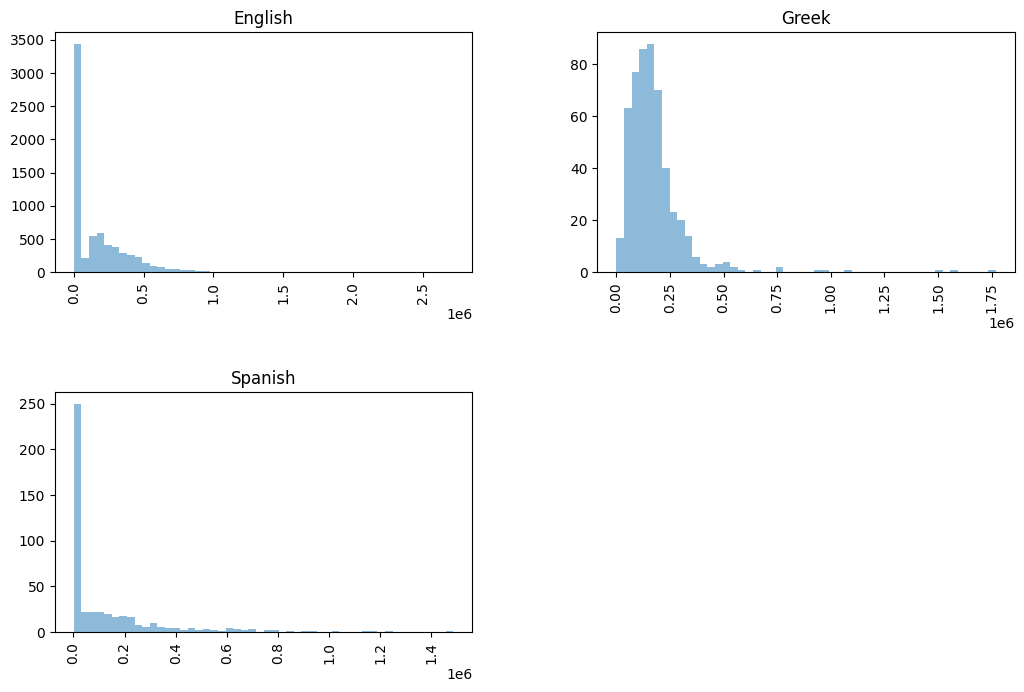

In [ ]:
fdf['text'].str.len().hist(by=fdf['language'], bins=50, figsize=(12, 8), alpha=0.5)

### Evaluation results

In [56]:
en  # source_doc, variant

,source_doc,eval_type,eval_method,variant,score,duration
0,10023,N-gram,Rouge1,source,1.000000,1.271085
1,10023,N-gram,Rouge2,source,1.000000,1.271570
2,10023,Graph-based,AutoSummENG,source,1.000000,0.616590
3,10023,Graph-based,MeMoG,source,1.000000,0.616590
4,10023,Meta,NPowER,source,0.888240,0.616590
...,...,...,...,...,...,...
69531,11690,Graph-based,MeMoG,10067_1,0.093921,0.444298
69532,11690,Meta,NPowER,10067_1,0.136575,0.444298
69533,11690,Embeddings-based,BERTScore,10067_1,0.826652,0.153589
69534,11690,Embeddings-based,BARTScore,10067_1,-4.655328,0.190637


In [2]:
en = pd.read_csv('results/English.csv')  # ver: _1
el = pd.read_csv('results/Greek.csv')  # ver: _2
es = pd.read_csv('results/Spanish.csv')  # ver: _GS1
dfs = [en, el, es]

In [ ]:
from src.modules.tokenizer import Tokenizer
tokenizer = Tokenizer(lang_code='en')
df = df.copy()
df['source_doc_char_count'] = df['source_doc'].apply(lambda x: len(x))
df['candidate_char_count'] = df['candidate'].apply(lambda x: len(x))
df['source_doc_word_count'] = df['source_doc'].apply(lambda x: len(x.split()))
df['candidate_word_count'] = df['candidate'].apply(lambda x: len(x.split()))
df['source_doc_sentence_count'] = df['source_doc'].apply(lambda x: len(re.findall(r'\w+[.!?]', x)))
df['candidate_sentence_count'] = df['candidate'].apply(lambda x: len(re.findall(r'\w+[.!?]', x)))

In [ ]:
for df in dfs:
    df = df.copy()
    df['source_doc_char_count'] = df['source_doc'].apply(lambda x: len(x))
    df['candidate_char_count'] = df['candidate'].apply(lambda x: len(x))
    df['source_doc_word_count'] = df['source_doc'].apply(lambda x: len(x.split()))
    df['candidate_word_count'] = df['candidate'].apply(lambda x: len(x.split()))
    df['source_doc_sentence_count'] = df['source_doc'].apply(lambda x: len(re.findall(r'\w+[.!?]', x)))
    df['candidate_sentence_count'] = df['candidate'].apply(lambda x: len(re.findall(r'\w+[.!?]', x)))

In [ ]:
# All datasets - Basic preprocessing
for df in dfs:
    df['variant_type'] = df['variant']

    # Find the random summaries (starts with a digit and contains '_')
    df.loc[(df['variant'].str[0].str.isdigit()) & (df['variant'].str.contains('_')), 'variant_type'] = 'random_summary'

    # Find the noise variants (contain a percentage) and extract that percentage
    noise_variants = df['variant_type'].str.contains(r'[A-Za-z_]0\.\d$', regex=True)
    df.loc[:, 'noise_percentage'] = df.loc[noise_variants, 'variant_type'].str[-3:]

    # The source is a 0% of noise
    df.loc[df['variant_type'] == 'source', 'noise_percentage'] = '0.0'

    # Extract the noise variant string
    df.loc[noise_variants, 'variant_type'] = df.loc[noise_variants, 'variant_type'].str[:-4]


# English only - Normalize (min-max) the scores for BARTScore and Bleurt for better interpretation
for method in ['BARTScore', 'Bleurt']:
    method_scores = en['eval_method'] == method
    scores = en.loc[method_scores, 'score']
    min_val = scores.min()
    max_val = scores.max()
    en.loc[method_scores, 'score'] = (scores - min_val) / (max_val - min_val)

In [7]:
en.loc[en['eval_method'] == 'BARTScore', ['variant_type', 'score']].max()

variant_type      source
score          -0.777206
dtype: object

In [ ]:
# Correlation
en['language'] = 'English'
el['language'] = 'Greek'
es['language'] = 'Spanish'

full_df = pd.concat([en, el, es], ignore_index=True)

correlations = []

for method in ['pearson', 'spearman', 'kendall']:
    corr = (
        full_df
        .groupby(['language', 'variant_type', 'eval_method'])[['score', 'noise_percentage']]
        .corr(method=method)
        .rename(columns={'score': method})
        .drop(index='score', level=-1)
        .reset_index(level=3, drop=True)
        .drop(columns=['noise_percentage'])
        .reset_index()
    )
    if method != 'pearson':
        corr = corr[[method]]
    correlations.append(corr)

final_corr = pd.concat(correlations, axis=1)
final_corr = final_corr[~final_corr['variant_type'].isin(['source', 'random_summary'])]
final_corr

,language,variant_type,eval_method,pearson,spearman,kendall
0,English,consecutively_swapped_words,AutoSummENG,-0.879488,-0.902199,-0.784380
1,English,consecutively_swapped_words,BARTScore,-0.543549,-0.654290,-0.507542
2,English,consecutively_swapped_words,BERTScore,-0.822322,-0.860132,-0.727420
3,English,consecutively_swapped_words,Bleurt,-0.008734,-0.005224,-0.003797
4,English,consecutively_swapped_words,MeMoG,-0.879488,-0.902199,-0.784380
...,...,...,...,...,...,...
149,Spanish,repeated_sentence,BERTScore,-0.729691,-0.705556,-0.553171
150,Spanish,repeated_sentence,MeMoG,-0.216335,-0.241103,-0.177645
151,Spanish,repeated_sentence,NPowER,-0.216336,-0.241108,-0.177645
152,Spanish,repeated_sentence,Rouge1,-0.773582,-0.791174,-0.641467


#### Random summary

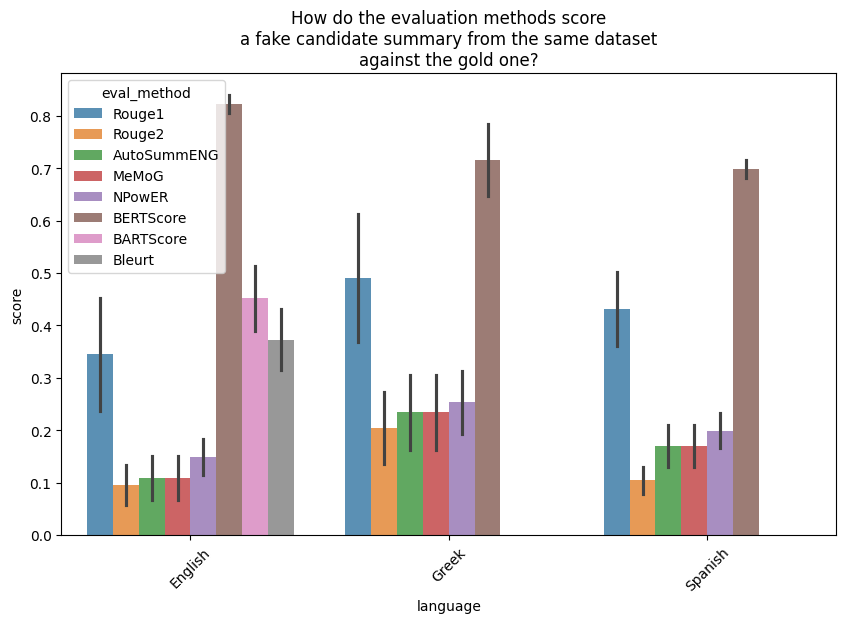

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=full_df[full_df['variant_type'] == 'random_summary'], x='language', y='score', hue='eval_method', alpha=0.8, errorbar='sd')
plt.title('How do the evaluation methods score\na fake candidate summary from the same dataset\nagainst the gold one?')
plt.xticks(rotation=45)
plt.show()

In [40]:
full_df[full_df['variant_type'] == 'random_summary'].groupby(['language'])['score'].skew()

language
English    0.992406
Greek      0.850122
Spanish    0.990610
Name: score, dtype: float64

#### Randomly swapped words

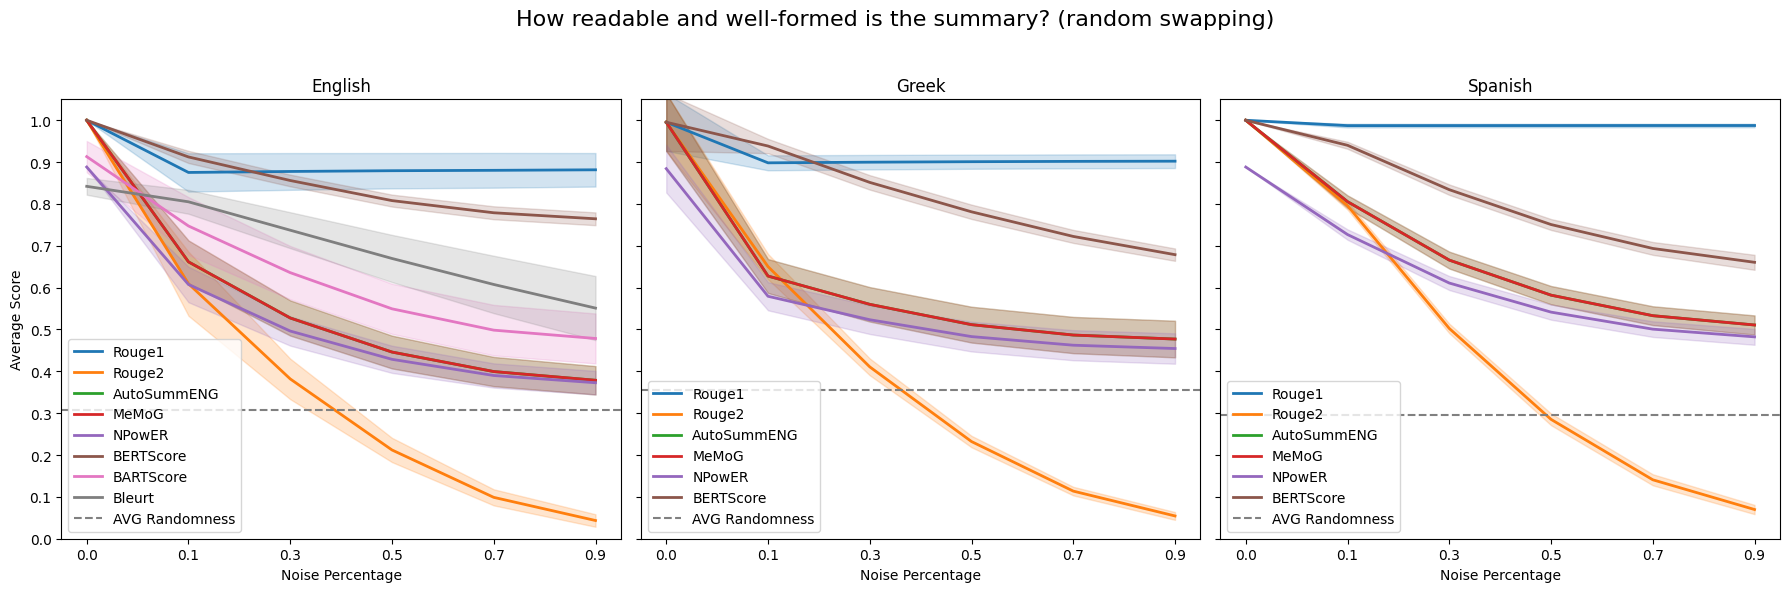

eval_method,pearson,spearman,kendall
AutoSummENG,-0.885936,-0.892889,-0.769487
BERTScore,-0.939774,-0.945705,-0.840761
MeMoG,-0.885936,-0.892889,-0.769487
NPowER,-0.885936,-0.892890,-0.769489
Rouge1,0.050756,0.068789,0.050720
Rouge2,-0.951199,-0.963067,-0.875461
eval_method,pearson,spearman,kendall
AutoSummENG,-0.759114,-0.761627,-0.605947
BERTScore,-0.976705,-0.976451,-0.888749
MeMoG,-0.759114,-0.761627,-0.605947


eval_method,pearson,spearman,kendall
BARTScore,-0.815663,-0.847751,-0.706780
Bleurt,-0.844249,-0.874287,-0.748071


In [28]:
plot_scores(dfs=dfs, title='How readable and well-formed is the summary? (random swapping)', noise_variant='randomly_swapped_words')
t_corr_all(df=final_corr, noise_variant='randomly_swapped_words')
t_corr(df=final_corr, noise_variant='randomly_swapped_words', lang='English', lang_specific=True)

#### Consecutively swapped words

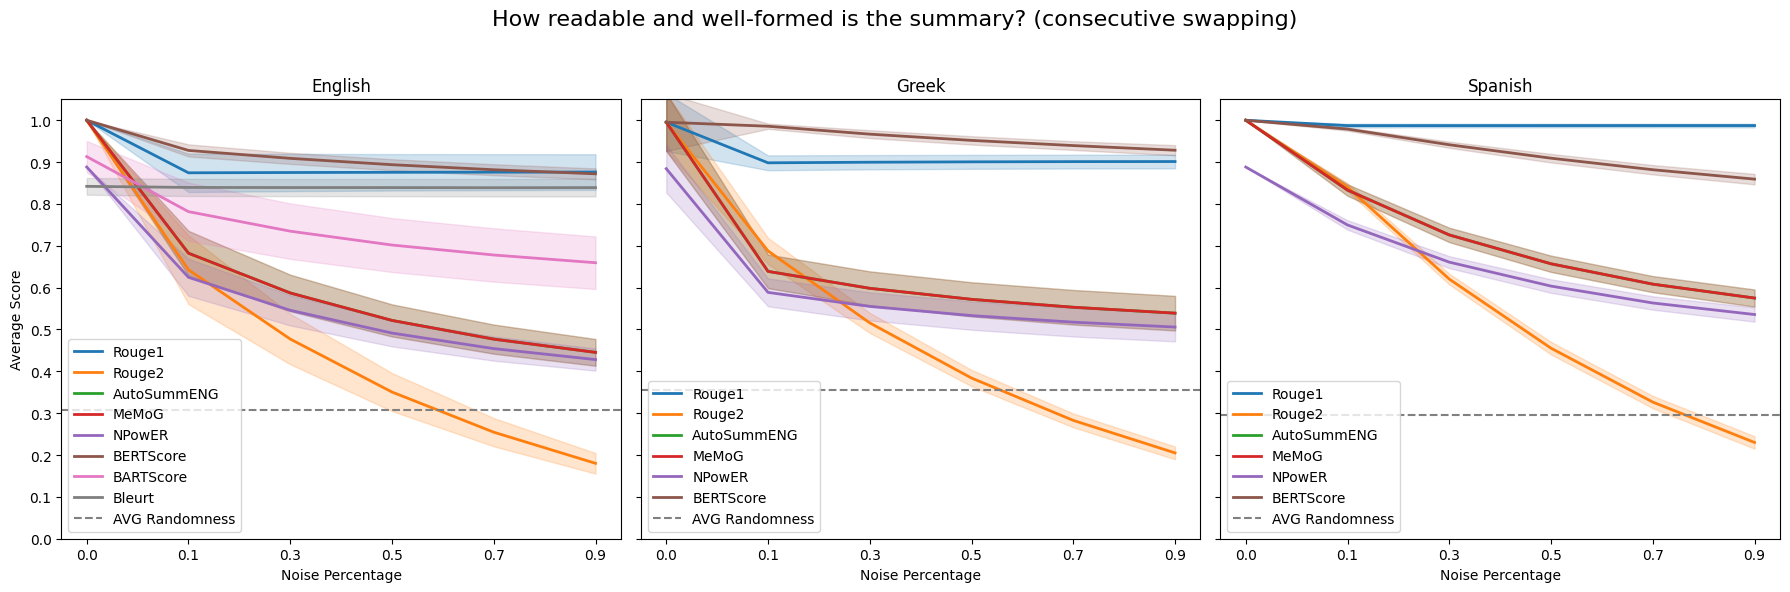

eval_method,pearson,spearman,kendall
AutoSummENG,-0.879488,-0.902199,-0.784380
BERTScore,-0.822322,-0.860132,-0.727420
MeMoG,-0.879488,-0.902199,-0.784380
NPowER,-0.879488,-0.902198,-0.784377
Rouge1,0.014459,0.016350,0.012241
Rouge2,-0.939873,-0.951366,-0.863914
eval_method,pearson,spearman,kendall
AutoSummENG,-0.641987,-0.648511,-0.501826
BERTScore,-0.894358,-0.910330,-0.790338
MeMoG,-0.641987,-0.648511,-0.501826


eval_method,pearson,spearman,kendall
BARTScore,-0.543549,-0.654290,-0.507542
Bleurt,-0.008734,-0.005224,-0.003797


In [29]:
plot_scores(dfs=dfs, title='How readable and well-formed is the summary? (consecutive swapping)', noise_variant='consecutively_swapped_words')
t_corr_all(df=final_corr, noise_variant='consecutively_swapped_words')
t_corr(df=final_corr, noise_variant='consecutively_swapped_words', lang='English', lang_specific=True)

#### Removed words

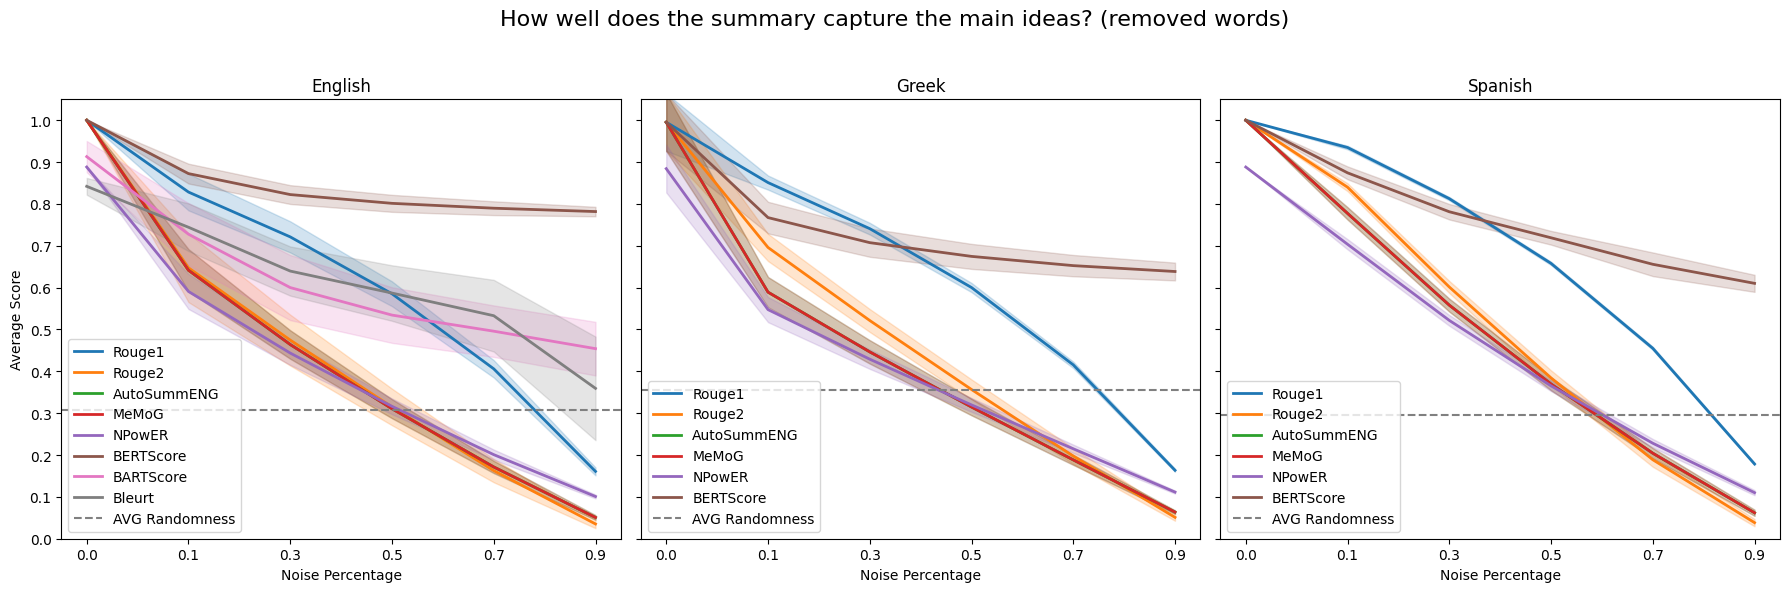

eval_method,pearson,spearman,kendall
AutoSummENG,-0.987339,-0.976230,-0.889024
BERTScore,-0.800690,-0.814855,-0.664598
MeMoG,-0.987339,-0.976230,-0.889024
NPowER,-0.987339,-0.976230,-0.889025
Rouge1,-0.978478,-0.973990,-0.885971
Rouge2,-0.971840,-0.965005,-0.876816
eval_method,pearson,spearman,kendall
AutoSummENG,-0.992040,-0.979770,-0.894806
BERTScore,-0.804379,-0.817086,-0.667755
MeMoG,-0.992040,-0.979770,-0.894806


eval_method,pearson,spearman,kendall
BARTScore,-0.781650,-0.815456,-0.670588
Bleurt,-0.818129,-0.858388,-0.717986


In [30]:
plot_scores(dfs=dfs, title='How well does the summary capture the main ideas? (removed words)', noise_variant='deleted_words')
t_corr_all(df=final_corr, noise_variant='deleted_words')
t_corr(df=final_corr, noise_variant='deleted_words', lang='English', lang_specific=True)

#### Removed sentence

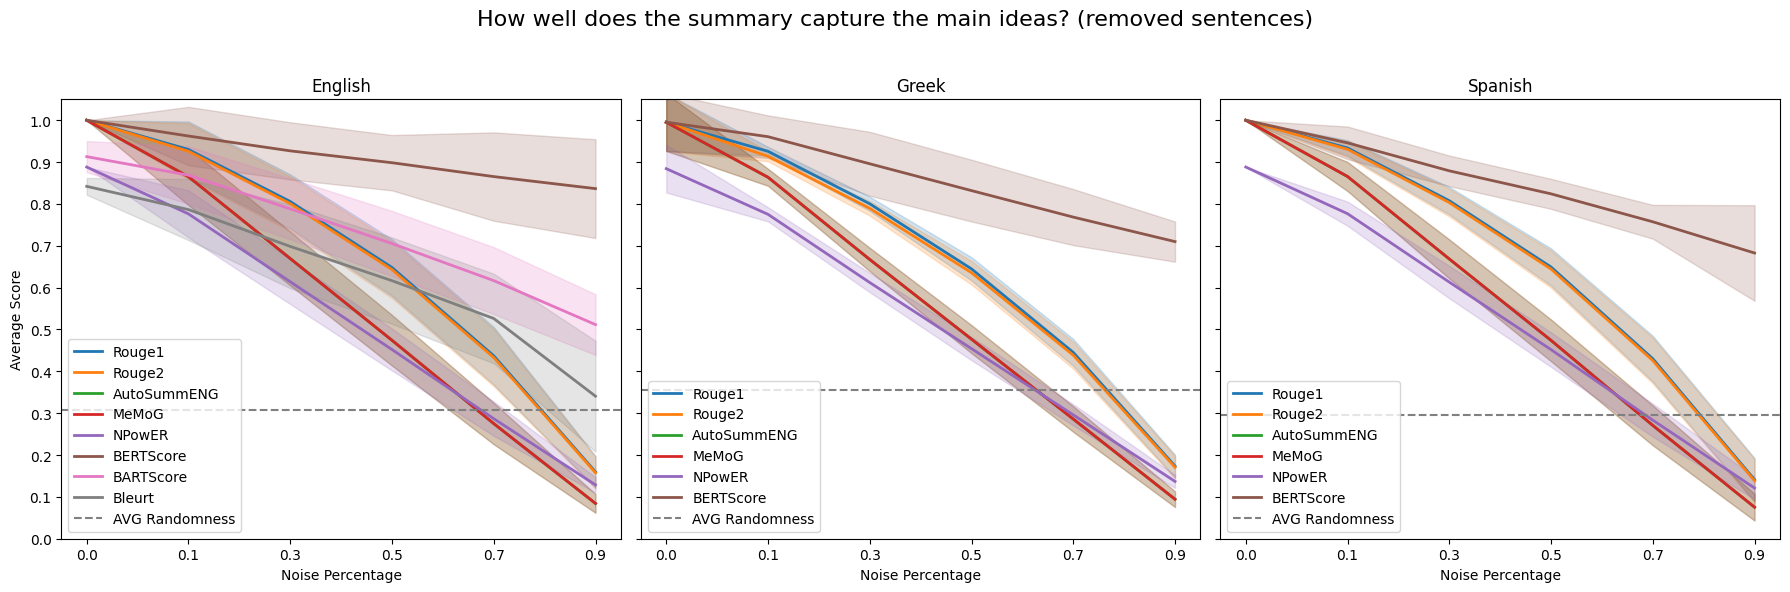

eval_method,pearson,spearman,kendall
AutoSummENG,-0.980644,-0.967178,-0.880246
BERTScore,-0.448864,-0.877398,-0.740019
MeMoG,-0.980644,-0.967178,-0.880246
NPowER,-0.980644,-0.967178,-0.880247
Rouge1,-0.962857,-0.967173,-0.880219
Rouge2,-0.963205,-0.967127,-0.880138
eval_method,pearson,spearman,kendall
AutoSummENG,-0.995170,-0.979750,-0.894769
BERTScore,-0.810928,-0.815428,-0.663576
MeMoG,-0.995170,-0.979750,-0.894769


eval_method,pearson,spearman,kendall
BARTScore,-0.859141,-0.908171,-0.785428
Bleurt,-0.811374,-0.829831,-0.682062


In [31]:
plot_scores(dfs=dfs, title='How well does the summary capture the main ideas? (removed sentences)', noise_variant='removed_sentence')
t_corr_all(df=final_corr, noise_variant='removed_sentence')
t_corr(df=final_corr, noise_variant='removed_sentence', lang='English', lang_specific=True)

#### Inserted sentence

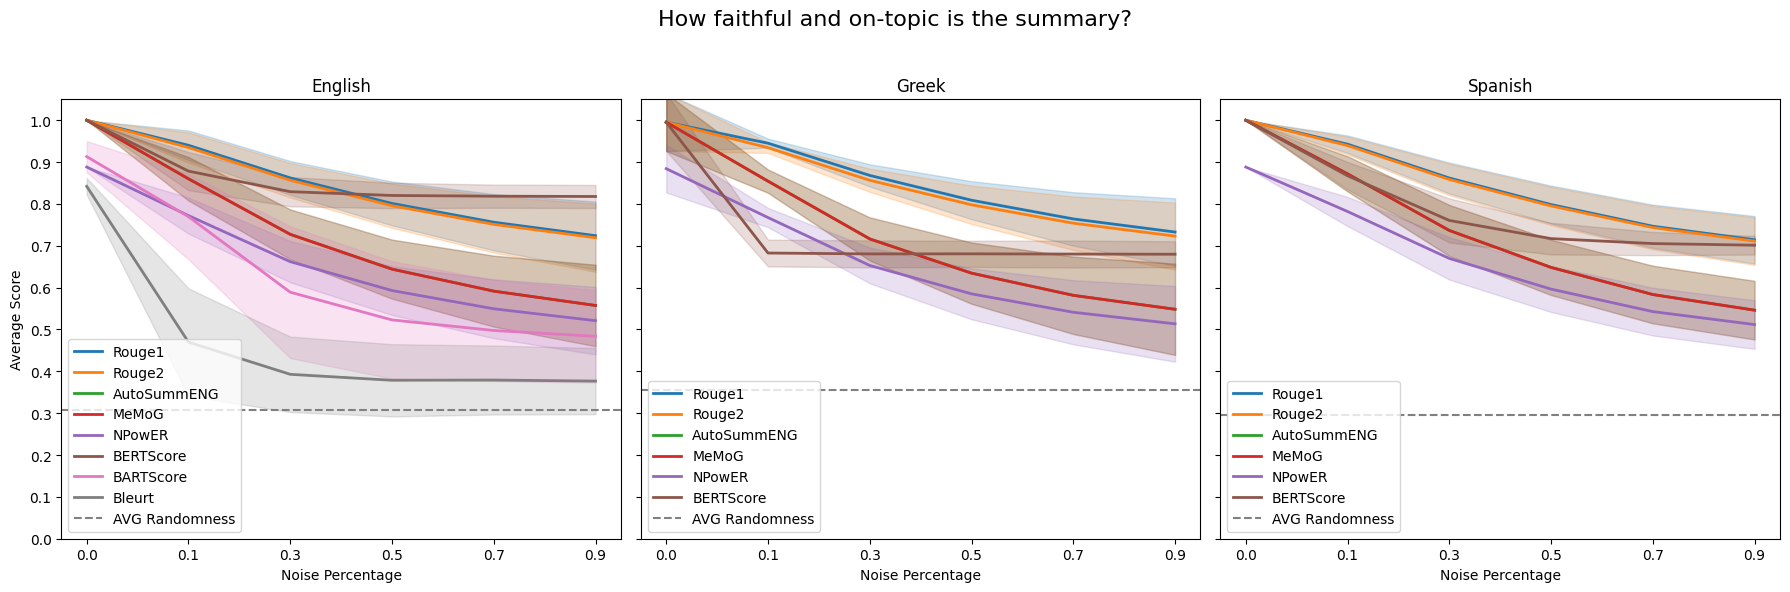

eval_method,pearson,spearman,kendall
AutoSummENG,-0.797043,-0.800824,-0.667683
BERTScore,-0.455219,-0.395212,-0.290416
MeMoG,-0.797043,-0.800824,-0.667683
NPowER,-0.797043,-0.800825,-0.667687
Rouge1,-0.789321,-0.813245,-0.681672
Rouge2,-0.786496,-0.811141,-0.678954
eval_method,pearson,spearman,kendall
AutoSummENG,-0.791528,-0.791100,-0.661322
BERTScore,-0.027585,-0.041629,-0.030467
MeMoG,-0.791528,-0.791100,-0.661322


eval_method,pearson,spearman,kendall
BARTScore,-0.567967,-0.550099,-0.412516
Bleurt,-0.279297,-0.235120,-0.173286


In [32]:
plot_scores(dfs=dfs, title='How faithful and on-topic is the summary?', noise_variant='inserted_sentence')
t_corr_all(df=final_corr, noise_variant='inserted_sentence')
t_corr(df=final_corr, noise_variant='inserted_sentence', lang='English', lang_specific=True)

#### Repeated sentence

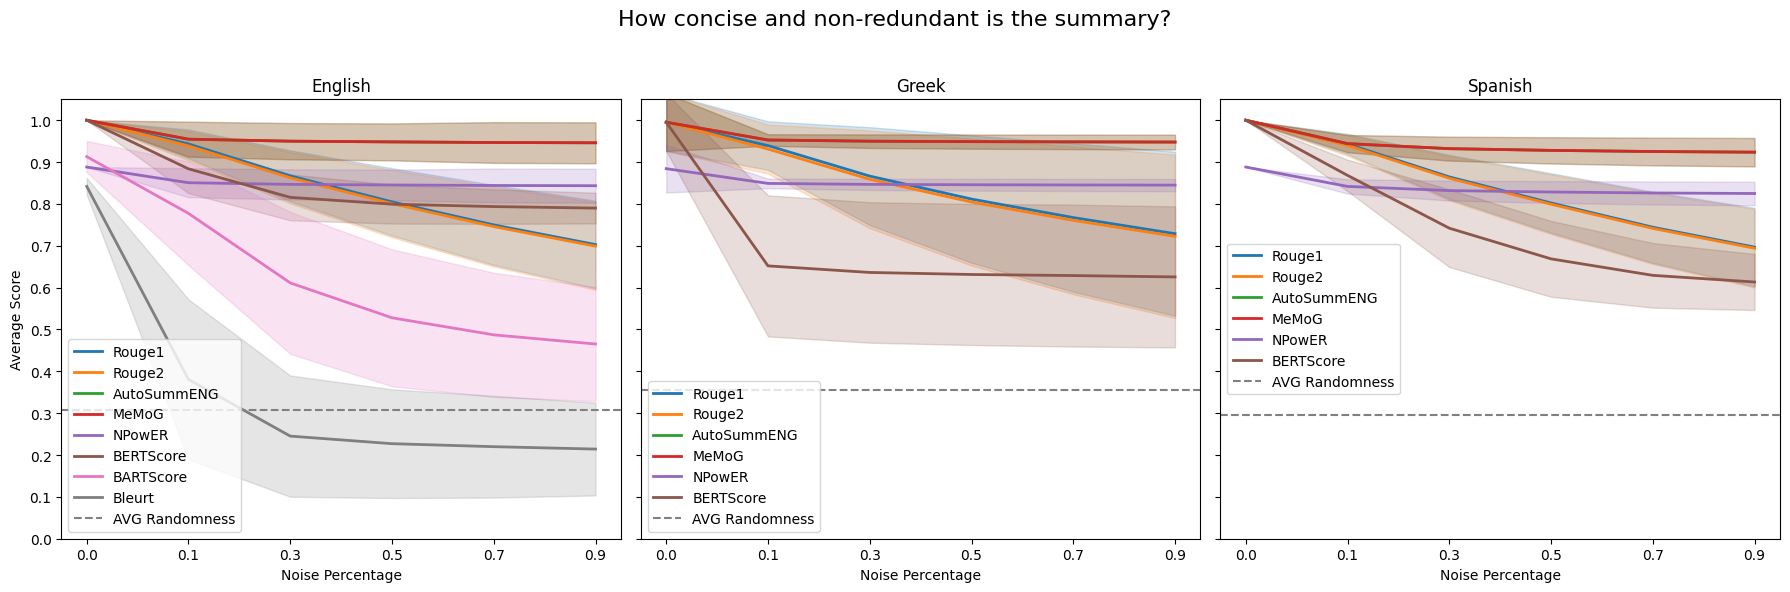

eval_method,pearson,spearman,kendall
AutoSummENG,-0.063538,-0.143317,-0.105764
BERTScore,-0.499887,-0.442065,-0.327589
MeMoG,-0.063538,-0.143317,-0.105764
NPowER,-0.063538,-0.143312,-0.105762
Rouge1,-0.728839,-0.766237,-0.621267
Rouge2,-0.727222,-0.764953,-0.619694
eval_method,pearson,spearman,kendall
AutoSummENG,-0.098149,-0.123983,-0.091397
BERTScore,-0.050543,-0.061371,-0.045117
MeMoG,-0.098149,-0.123983,-0.091397


eval_method,pearson,spearman,kendall
BARTScore,-0.565532,-0.550125,-0.418708
Bleurt,-0.326369,-0.291138,-0.213348


In [33]:
plot_scores(dfs=dfs, title='How concise and non-redundant is the summary?', noise_variant='repeated_sentence')
t_corr_all(df=final_corr, noise_variant='repeated_sentence')
t_corr(df=final_corr, noise_variant='repeated_sentence', lang='English', lang_specific=True)

#### Latency

In [49]:
print('Duration per language\n----------------------')
full_df.groupby(['language']).agg('duration').describe()

Duration per language
----------------------


,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
English,69536.0,0.361064,0.313163,0.0,0.093383,0.336221,0.506737,3.450141
Greek,2460.0,2.789413,3.748375,0.0,0.018180,0.943171,4.099589,18.436788
Spanish,2460.0,0.165987,0.141331,0.0,0.014969,0.187673,0.303990,0.459589


In [14]:
print('Duration per language per eval type and method\n-----------------------------------------------')
full_df.groupby(['language', 'eval_type', 'eval_method']).agg('duration').describe()

Duration per language per eval type and method
-----------------------------------------------


count      mean       std       min  \
language eval_type        eval_method                                         
English  Embeddings-based BARTScore    8692.0  0.114414  0.048573  0.009426   
                          BERTScore    8692.0  0.117707  0.086103  0.000000   
                          Bleurt       8692.0  0.028141  0.015651  0.000000   
         Graph-based      AutoSummENG  8692.0  0.463835  0.149972  0.170381   
                          MeMoG        8692.0  0.463835  0.149972  0.170381   
         Meta             NPowER       8692.0  0.463835  0.149972  0.170381   
         N-gram           Rouge1       8692.0  0.618704  0.395092  0.000000   
                          Rouge2       8692.0  0.618039  0.394990  0.000000   
Greek    Embeddings-based BERTScore    8662.0  0.549208  0.273918  0.059505   
         Graph-based      AutoSummENG  8662.0  6.042686  5.404255  0.265152   
                          MeMoG        8662.0  6.042686  5.404255  0.265152   
         Meta             NPowER       8662.0  6.042686  5.404255  0.265152   
         N-gram           Rouge1       8662.0  2.363095  1.600194  0.000000   
                          Rouge2       8662.0  2.347859  1.585370  0.000000   
Spanish  Embeddings-based BERTScore    7126.0  0.120829  0.048809  0.005427   
         Graph-based      AutoSummENG  7126.0  0.480114  0.166813  0.299873   
                          MeMoG        7126.0  0.480114  0.166813  0.299873   
         Meta             NPowER       7126.0  0.480114  0.166813  0.299873   
         N-gram           Rouge1       7126.0  0.108116  0.033942  0.007828   
                          Rouge2       7126.0  0.106150  0.044422  0.006048   

                                            25%       50%       75%        max  
language eval_type        eval_method                                           
English  Embeddings-based BARTScore    0.078887  0.099977  0.144159   0.427326  
                          BERTScore    0.047788  0.072260  0.173224   0.458219  
                          Bleurt       0.015968  0.026502  0.033004   0.174292  
         Graph-based      AutoSummENG  0.359543  0.440038  0.538970   1.415558  
                          MeMoG        0.359543  0.440038  0.538970   1.415558  
         Meta             NPowER       0.359543  0.440038  0.538970   1.415558  
         N-gram           Rouge1       0.342443  0.521653  0.813243   3.450141  
                          Rouge2       0.345188  0.522995  0.812404   3.426067  
Greek    Embeddings-based BERTScore    0.380348  0.488670  0.625044   3.254155  
         Graph-based      AutoSummENG  2.986750  4.552967  6.846923  68.288017  
                          MeMoG        2.986750  4.552967  6.846923  68.288017  
         Meta             NPowER       2.986750  4.552967  6.846923  68.288017  
         N-gram           Rouge1       1.384653  1.989345  2.796468  27.922611  
                          Rouge2       1.369552  1.967058  2.784851  24.398129  
Spanish  Embeddings-based BERTScore    0.083692  0.137114  0.160547   0.445409  
         Graph-based      AutoSummENG  0.425246  0.461036  0.501012   5.230542  
                          MeMoG        0.425246  0.461036  0.501012   5.230542  
         Meta             NPowER       0.425246  0.461036  0.501012   5.230542  
         N-gram           Rouge1       0.082657  0.110566  0.130664   0.424377  
                          Rouge2       0.080007  0.110551  0.126827   2.067432

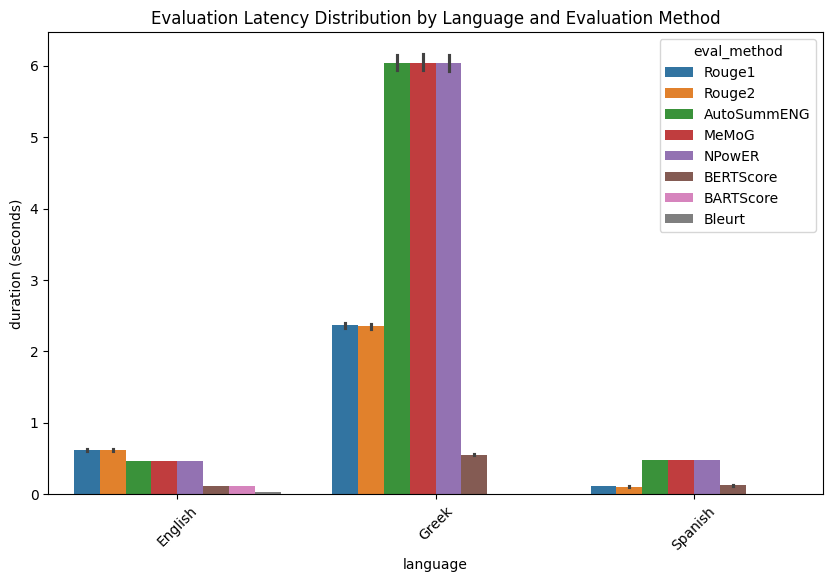

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(data=full_df, x='language', y='duration', hue='eval_method')
plt.title('Evaluation Latency Distribution by Language and Evaluation Method')
plt.xticks(rotation=45)
plt.ylabel('duration (seconds)')
plt.show()

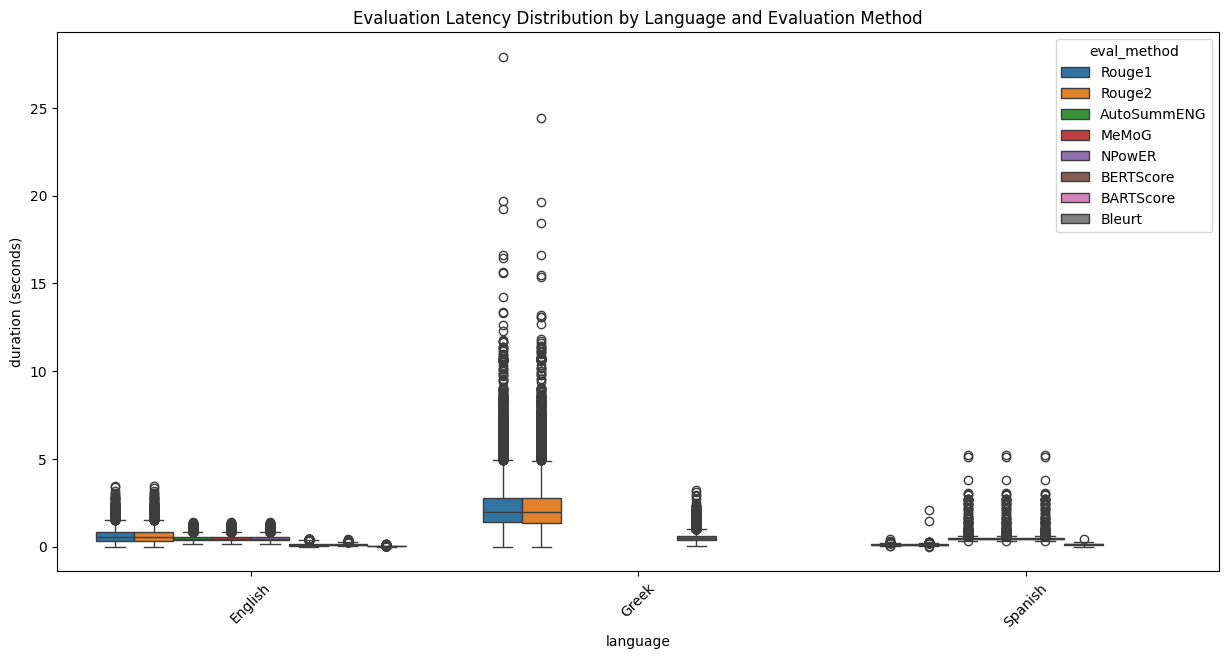

In [16]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=full_df[~(full_df['eval_type'].isin(['Graph-based', 'Meta'])) | (full_df['language'] != 'Greek')], x='language', y='duration', hue='eval_method')
plt.title('Evaluation Latency Distribution by Language and Evaluation Method')
plt.xticks(rotation=45)
plt.ylabel('duration (seconds)')
plt.show()

In [ ]:
df_summary = df.groupby(['eval_type', 'variant_type'])['score'].describe().reset_index().drop(columns='count')

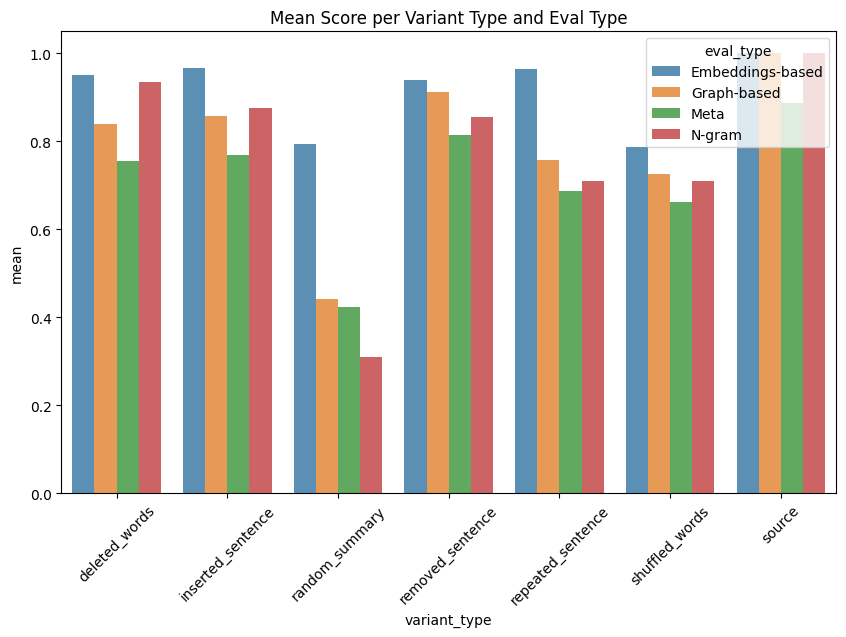

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_summary, x='variant_type', y='mean', hue='eval_type', alpha=0.8, errorbar=None)
plt.title('Mean Score per Variant Type and Eval Type')
plt.xticks(rotation=45)
plt.show()